
$A_{eff} = A_{min} = 59.1 mm^2 = 5.91e^{-5} m^2$

$\phi_{max} = B_{max} * A_{eff}$

$N_{min} = \frac{L*I_{pk}}{\phi_{max}}$

In [64]:
import math
import numpy as np
# Requirements/Given values
L = 20e-6 * 0.8 # in H, given 20% negative tolerance
Ipk = 6 # in A
B_max = 200e-3 # in T
A_rms = 10e6 # in A_rms/m^2
u_0 = 4*math.pi*1e-7 # permeability of free space in H/m

# nominal values of outer and inner diameter of the winding
D_winding_outer = 18e-3 # m
D_winding_inner = 8.8e-3 # m

A_min = 5.91e-5 # in m^2
phi_max = B_max * A_min
N_min = (L*Ipk)/phi_max
print("Minimum number of turns: ", N_min)

Minimum number of turns:  8.121827411167514


In [65]:
# Parameters:
wire_diameter = 0.511e-3/2 # in m
A_wire = math.pi * ((wire_diameter/2)**2) # wire cross-sectional area in m^2
k = 0.8 # fill factor
N = 11 # number of turns ~ 11
ind_height = 14.30e-3 # m
print(f"Max number of turns of this wire possible in inductor: {math.floor(ind_height/wire_diameter)}")

print("Wire diameter: ", wire_diameter, "m")
print("Wire cross-sectional area: ", A_wire, "m^2")
print("Number of turns: ", N)

Max number of turns of this wire possible in inductor: 55
Wire diameter:  0.0002555 m
Wire cross-sectional area:  5.127098845612627e-08 m^2
Number of turns:  11


$W = \frac{L*I^2}{2}$

In [66]:
W = (L*Ipk**2)/2 # Calculated work of inductor
print(f"Work: {W}")
J_max = Ipk/A_wire # maximum current density in the wire
Aw = math.pi * (D_winding_outer**2 - D_winding_inner**2)/4
print("Area of winding: ", Aw, "m^2")
print("current density: ", J_max, "A/m^2")
F_max = J_max * k * Aw

Work: 0.00028800000000000006
Area of winding:  0.0001936477711672748 m^2
current density:  117025245.28338934 A/m^2


In [67]:
R_min = (2*W)/(phi_max**2) # minimum reluctance of the air gap
R_max = (F_max**2)/(2*W)

print(f"Minimum reluctance: {R_min:.3e}")
print(f"Maximum reluctance: {R_max:.3e}")
print(f"Range of l_eg: {R_min*(u_0*A_min)*10e3:.3e} mm to {R_max*(u_0*A_min)*10e3:.3e} mm\n")

Minimum reluctance: 4.123e+06
Maximum reluctance: 5.706e+11
Range of l_eg: 3.062e+00 mm to 4.238e+05 mm



In [68]:
l_eg_in = 0.01765 # in
l_eg = l_eg_in * 0.0254 # m
R_e= l_eg/(u_0 * A_min) # reluctance of the air gap
L = 11**2 * (1/R_e)

print(f"Reluctance of the air gap: {R_e:.3e}")
print(f"Inductance with air gap: {L:.3e} H")

Reluctance of the air gap: 6.036e+06
Inductance with air gap: 2.004e-05 H


INSERT SKIN DEPTH CALCULATOR WITH WIRE GAUGE

Using matplotlib backend: inline
slope: 36876.044336668376
intercept: 0.09619034033250581


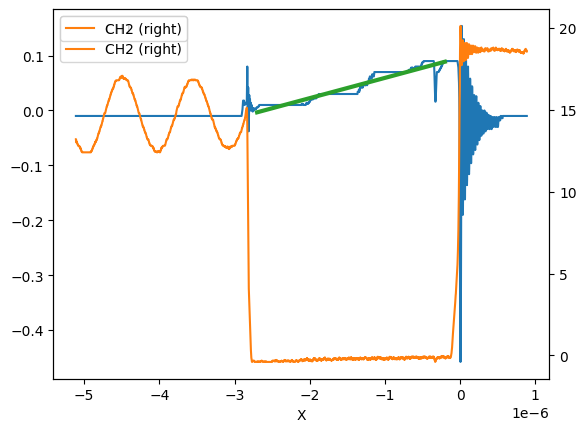

The measured inductance value is 1.996285e-05


In [69]:
import pandas as pd
import csv
import matplotlib.pyplot as plt
from scipy.stats import linregress
%matplotlib
%matplotlib inline
pd.set_option('display.float_format', lambda x: '%e' % x)

def read_rigol_csv(csv_file_name):
    with open(csv_file_name) as f:
        rows = list(csv.reader(f))

    i = 0
    while rows[0][i] != "":
        i = i + 1

    numcols = i - 2
    t0 = float(rows[1][numcols])
    dT = float(rows[1][numcols+1])

    data = pd.read_csv(csv_file_name, usecols=range(0, numcols), skiprows=[1])
    data['X'] = t0 + data['X'] * dT

    return data, t0, dT

[data, t0, dT] = read_rigol_csv('data/100zi.csv')

Vg = 18

fig, ax = plt.subplots()
data['CH1'] = data['CH1'].rolling(10, min_periods=1).mean()
data['CH2'] = data['CH2'].rolling(10, min_periods=1).mean()
data.plot(x="X", y="CH1", ax = ax)
data.plot(x="X", y="CH2", ax = ax, secondary_y = True)

# choose the X range
x1 = -2.7e-6
x2 = -0.2e-6

subset = data[(data['X'] >= x1) & (data['X'] <= x2)]
result = linregress(subset['X'], subset['CH1'])

slope = result.slope
di_dt = 37400/0.05
intercept = result.intercept

print("slope:", slope)
print("intercept:", intercept)

# plot result
fit = slope * subset['X'] + intercept

ax.plot(subset['X'], fit, linewidth=3, label='fit')
plt.legend()
plt.show()

Vout = 3.30 #measured voltage output
Avg_Vd = np.mean(subset['CH2'])

# Vg = Vout + Avg_Vd + Vind
Vind = Vg - Vout - Avg_Vd

print(f"The measured inductance value is {Vind/di_dt:3e}")

slope: 29893.139321459927
intercept: 0.19848666414651828


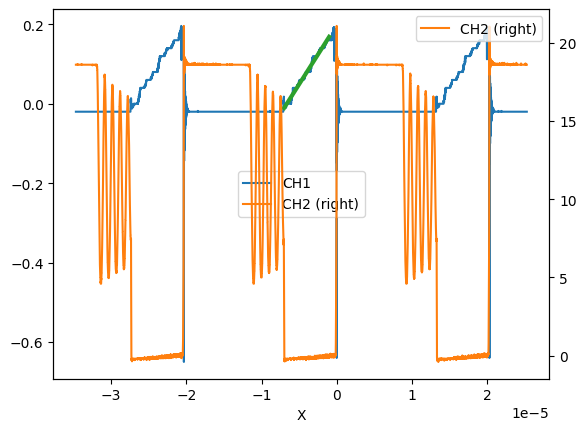

The measured inductance value is 1.910988e-05
(30000, 3)


In [74]:
[data, t0, dT] = read_rigol_csv('data/q4.csv')

fig, ax = plt.subplots()
data['CH1'] = data['CH1'].rolling(10, min_periods=1).mean()
data['CH2'] = data['CH2'].rolling(10, min_periods=1).mean()
data.plot(x="X", y="CH1", ax = ax)
data.plot(x="X", y="CH2", ax = ax, secondary_y = True)

# choose the X range
x1 = -0.7e-5
x2 = -0.1e-5

# filter the data
subset = data[(data['X'] >= x1) & (data['X'] <= x2)]

# perform linear regression
result = linregress(subset['X'], subset['CH1'])

slope = result.slope
# di_dt = slope/0.05
di_dt = 26775.57/0.05
intercept = result.intercept

print("slope:", slope)
print("intercept:", intercept)

# plot result
fit = slope * subset['X'] + intercept

ax.plot(subset['X'], fit, linewidth=3, label='fit')
plt.legend()
plt.show()

Vout = 7.91 #measured voltage output
Avg_Vd = np.mean(subset['CH2'])

# Vg = Vout + Avg_Vd + Vind
Vind = Vg - Vout - Avg_Vd

print(f"The measured inductance value is {Vind/di_dt:3e}")

slope: 37400.05406250939
intercept: -0.003855703587564291


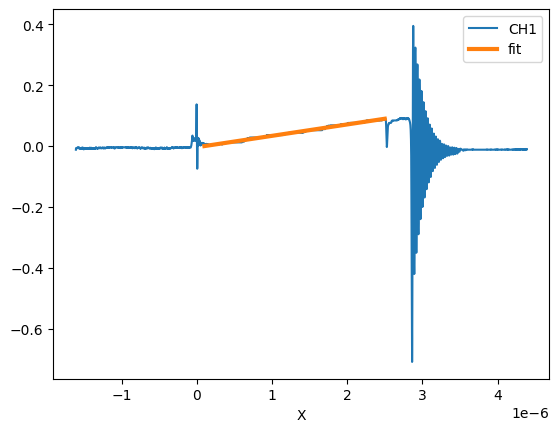

(6000, 2)


In [73]:
[data, t0, dT] = read_rigol_csv('data/NewFile1.csv')

fig, ax = plt.subplots()
data['CH1'] = data['CH1'].rolling(10, min_periods=1).mean()
data.plot(x="X", y="CH1", ax = ax)

# choose the X range
x1 = 0.1e-6
x2 = 2.5e-6

# filter the data
subset = data[(data['X'] >= x1) & (data['X'] <= x2)]

# perform linear regression
result = linregress(subset['X'], subset['CH1'])

slope = result.slope
intercept = result.intercept

print("slope:", slope)
print("intercept:", intercept)

# plot result
fit = slope * subset['X'] + intercept

plt.plot(subset['X'], fit, linewidth=3, label='fit')
plt.legend()
plt.show()

slope: 26775.579410432754
intercept: 0.19916101198919012


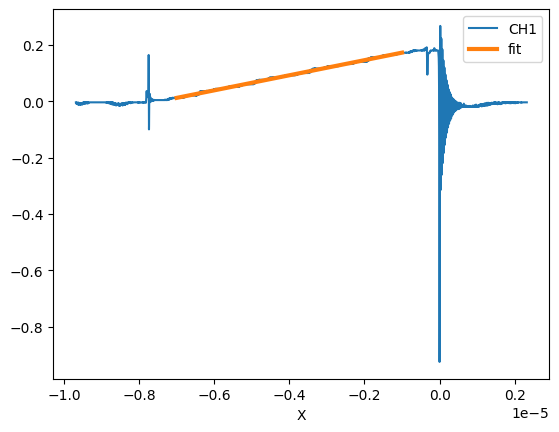

In [72]:
[data, t0, dT] = read_rigol_csv('data/200mV.csv')

fig, ax = plt.subplots()
data['CH1'] = data['CH1'].rolling(10, min_periods=1).mean()
data.plot(x="X", y="CH1", ax = ax)

# choose the X range
x1 = -0.7e-5
x2 = -0.1e-5

# filter the data
subset = data[(data['X'] >= x1) & (data['X'] <= x2)]

# perform linear regression
result = linregress(subset['X'], subset['CH1'])

slope = result.slope
intercept = result.intercept

print("slope:", slope)
print("intercept:", intercept)

# plot result
fit = slope * subset['X'] + intercept

plt.plot(subset['X'], fit, linewidth=3, label='fit')
plt.legend()
plt.show()